In [32]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS, summarize,poly)
import matplotlib.pyplot as plt
from statsmodels.stats.anova import anova_lm
import math

np.random.seed(0)

X = np.random.normal(loc=0, scale=1, size=100)
eps = np.random.normal(loc=0, scale=0.5, size=100)

y = -1 + 0.5 * X + eps
eps

array([ 0.94157535, -0.67387953, -0.6352425 ,  0.48469835, -0.5865617 ,
        0.97181059, -0.20680949, -0.37372741,  0.96147101,  0.7402574 ,
        0.93377948,  0.45302233, -0.43061284,  0.95503248, -0.13400169,
        0.4012282 ,  0.47362598, -0.07750505,  0.30703969,  0.46110334,
        0.18821277, -0.5497004 ,  0.14911909,  0.66319295, -0.34728393,
       -0.07481727, -0.21757678,  0.92463186,  0.33614738,  0.20373092,
       -0.38495804,  0.2696246 , -0.33716633,  0.01591528, -0.31792304,
        0.33821665,  0.28829541, -0.10414938,  0.19800336, -0.54653075,
       -0.7456288 ,  0.21969585,  0.08333675,  0.31751572,  1.19157239,
        0.47223974, -0.45641111,  0.55850814, -0.65795371, -0.2307923 ,
       -0.0341208 ,  0.85667136, -0.37237741, -0.41321927, -0.04922626,
       -0.33173914,  0.56331796, -0.53996575, -0.57373433, -0.21891002,
       -0.24901623,  0.96476603,  0.4747104 ,  0.04377562, -0.61271776,
        0.42218149, -0.50010767, -0.77238555,  0.5940149 ,  0.15

Длина вектора У - 100
В0 = -1
В1 = 0.5

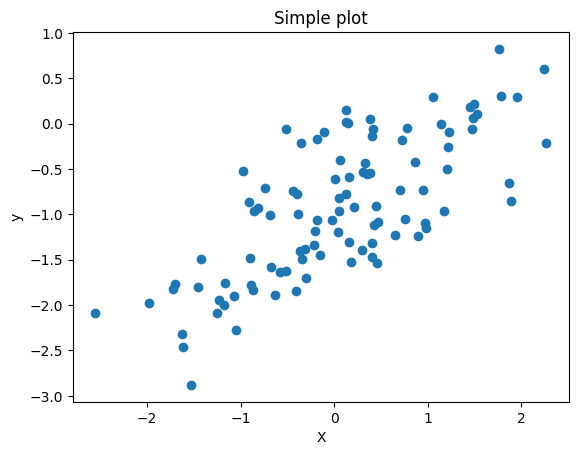

In [31]:
fig, ax = plt.subplots()
ax.scatter(X, y)
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Simple plot');

На графике заметна четка линейная зависимость между Х и У, причем даже по грпфику можно увидеть, что значение свободного члена около единицы.
Данные же распределены равномерно, что не удивительно ведь мы использовали распределение по Гаусу.

In [22]:
X_data = pd.DataFrame({'Intercept': 1, 'X': X})
results = sm.OLS(y,X_data).fit()
summarize(results)

,coef,std err,t,P>|t|
Intercept,-0.9812,0.026,-37.722,0.0
X,0.5287,0.026,20.521,0.0


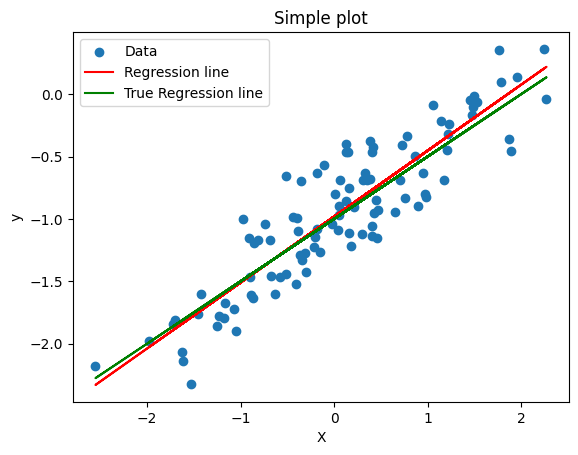

In [23]:
intercept = results.params.Intercept   
X_param = results.params.X

xlim = ax.get_xlim()
ylim = [X_param * xlim[0] + intercept, X_param * xlim[1] + intercept]

ax.plot(xlim, ylim, 'r--', linewidth=3);
plt.show()

fig, ax = plt.subplots()
ax.scatter(X, y, label="Data")
ax.plot(X, intercept + X_param * X, color='red', label="Regression line")
ax.plot(X, -1 + 0.5 * X, color='green', label="True Regression line")
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Simple plot')
ax.legend()
plt.show()

In [24]:
X_data_poly = pd.DataFrame({'Intercept': 1, 'X': X, 'X_poly': X ** 2})
results1 = sm.OLS(y,X_data_poly).fit()
summarize(results1)

,coef,std err,t,P>|t|
Intercept,-0.9643,0.033,-29.173,0.000
X,0.5308,0.026,20.473,0.000
X_poly,-0.0167,0.020,-0.830,0.409


In [25]:
anova_lm(results, results1)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,98.0,6.607324,0.0,NaN,NaN,NaN
1,97.0,6.560724,1.0,0.046601,0.688986,0.408548


Полиномиальная модель действительно прибавила немного в качестве, хотя и незначительно, тут конечно интересный момент, как
это скажется не предсказании результатов не на тестовом датасете, поскольку в реальности модель у нас линейная, а полиномиальность
привносит в нее некого рода нелинейность, что потенциально может снизить качество на контрольных данных

In [26]:
np.random.seed(0)
X1 = np.random.normal(loc=0,scale=0.5,size=100)
eps1 = np.random.normal(loc=0,scale=0.1,size=100)

y1 = -1 + 0.5 * X1 + eps1

X_data1 = pd.DataFrame({'Intercept': 1, 'X': X1})
results2 = sm.OLS(y1,X_data1).fit()
print('MSE1', results2.mse_total)
summarize(results2)

MSE1 0.05473525368055063


,coef,std err,t,P>|t|
Intercept,-0.9993,0.010,-104.545,0.0
X,0.4713,0.021,22.427,0.0


In [27]:
np.random.seed(0)
X2 = np.random.normal(loc=0,scale=1.5,size=100)
eps2 = np.random.normal(loc=0,scale=0.4,size=100)

y2 = -1 + 0.5 * X2 + eps2

X_data2 = pd.DataFrame({'Intercept': 1, 'X': X2})
results3 = sm.OLS(y2,X_data2).fit()
print('MSE2', results3.mse_total)
summarize(results3)

MSE2 0.5385580689933827


,coef,std err,t,P>|t|
Intercept,-0.9970,0.038,-26.078,0.0
X,0.4618,0.028,16.480,0.0


YНе сложно заметить, что если в данных меньше шума, то коэффициенты бета найдееные по МНК более близки к реальным,
чем в модели, обученной на данных с большим уровнем шума, хотя тут тоже все явно относительно,\
разница в коэффициентах между моделями не такая уж и большая, как и разница между коэффициентами, в теории чем больше
будет выборка для обучения тем по идее меньше должно быть влияние шума.